# Recovering rules from every CommonLII judgment (Track A2)

Goal: extract the legal **rule** from all 3,703 CommonLII reported judgments, and
link each rule to the statute sections its headnote names. The original
`Held:`-marker extractor only fired on 524 of them. This notebook uses a hardened,
structure-aware parser (**Track A2**) that reads the NLR/SLR headnote layout
directly:

```
[registry / case no.] -> [CATCHWORDS: topic - topic - topic. / ... ?] -> [RULE] -> [body start]
```

It is **deterministic and verbatim** (no LLM), and **precision-first**: when the
structure is not clean it **abstains** (those cases fall back to the bounded LLM
track) rather than emit something that is not a rule. The parser was hardened
case-by-case against every failure mode found in the corpus: `?`-terminated
catchwords, `Per JUDGE -` / `Withers, J. -` rule attributions, SLR headers,
section-dash catchwords (`s. 642-Application`), long multi-topic catchword lists,
and body-narrative bleed. A precision guard drops any candidate that is itself a
dash-topic list.

All output is `status=unverified` and lawyer-gated.

## 0. Setup

In [1]:
import json
import re
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROCESSED = ROOT / "data" / "processed"
OUT = ROOT / "evaluation" / "runs" / "headnote-recovery-v1"
OUT.mkdir(parents=True, exist_ok=True)

PAL = ["#2F6F5E", "#C08A2D", "#7A8B99", "#8A5510", "#4E6E5D", "#B0663A", "#3E5C6E"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

def barh(labels, values, title, xlabel="count", color=PAL[0]):
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(labels) + 1.2))
    ax.barh(range(len(labels)), values, color=color)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlabel(xlabel); ax.set_title(title, loc="left", fontweight="bold")
    for i, v in enumerate(values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()

print("repo root:", ROOT)

repo root: C:\Users\ASUS\Desktop\DSEP\Draftly


## 1. Load every CommonLII case

In [2]:
cases = pd.read_json(PROCESSED / "cases.jsonl", lines=True)
cl = cases[cases["source"] == "commonlii"].copy()
TEXT_PATH = dict(zip(cl["case_id"], cl["text_path"]))
CITATION = dict(zip(cl["case_id"], cl["citation"]))
YEAR = dict(zip(cl["case_id"], cl["year"]))
print(f"CommonLII cases: {len(cl):,}  (LKCA {int((cl['court']=='LKCA').sum())}, LKSC {int((cl['court']=='LKSC').sum())})")

def load_text(cid):
    rel = TEXT_PATH.get(cid)
    p = ROOT / rel if rel and not Path(rel).is_absolute() else Path(rel or "")
    return p.read_text(encoding="utf-8", errors="replace") if p.exists() else ""


CommonLII cases: 3,703  (LKCA 3330, LKSC 373)


## 2. The hardened Track A2 parser

In [3]:
# ---------- Track A2 parser (deterministic, verbatim; no LLM) ----------
import re

HEADER = re.compile(r"\(\d{4}\)\s+\d+\s+(?:NLR|Sri\s?LR|S\.?\s?L\.?\s?R\.?|New\s?L\.?\s?R\.?)\s+\d+\s*\([^)]*\)", re.I)
NAV = re.compile(r"(?:Home \| Databases|You are here|Feedback\b|\bHelp\b)")
BODY = re.compile(
    r"(?:THE|T\s?HE)\s+(?:facts?|plaintiffs?|defendants?|appellants?|respondents?|petitioners?|following|action|above)\b"
    r"|(?:THIS|T\s?HIS)\s+(?:action|appeal|application|suit|case)\s+(?:was|is|being)\b"
    r"|\bThe\s+(?:facts?|following)\b"
    r"|A\s?PPEAL\s+(?:from|against|by|is|was|to|and)"
    r"|A\s?PPLICATION\s+(?:for|by|to|was|is|made|under)"
    r"|Cur\.?\s*adv\.?\s*vult"
    r"|I[Nn]\s+this\s+(?:case|action|matter|suit|appeal|application)\b"
    r"|On\s+the\s+trial\b|At\s+the\s+trial\b"
    r"|[A-Z][\w. ]{2,30}?,?\s+for\s+(?:the\s+)?(?:appellant|respondent|plaintiff|defendant|petitioner|added|substituted|intervenient|accused)"
    r"|[A-Z][A-Za-z]+\s*,?\s?[AC]?\.?\s?[CJ]\.\s?[JI]?\.?\s*[—\-]\s")
HELD = re.compile(r"\bHeld\b\s*[:,\-—(]?", re.I)
HAS_LOWER = re.compile(r"[a-z]{3,}")
# topic dash (excludes registry "-D."); used for the rule-content catchword-list guard, kept narrow on purpose
DASH = re.compile(r"[A-Za-z0-9)\"'?][ ]?[—\-][ ]?[\"'(]?[A-Za-z]{2}")
# broadened: catchword-boundary detection only. � = corrupted em-dash from harvest
# encoding (899/3703 files affected), {1,2} covers "--" typeset dashes
DASH_CATCH = re.compile(r"[A-Za-z0-9)\"'?][ ]?[\u2014\-\ufffd]{1,2}[ ]?[\"'(]?[A-Za-z]{2}")
PER_LEAD = re.compile(
    r"^(?:Per\s+|PER\s+)?(?:[A-Z][A-Za-z']+\.?\s*){1,3},?\s*(?:[ACJ]\.\s?){1,3}"
    r"(?:(?:and|&|,)\s+(?:[A-Z][A-Za-z']+\.?\s*){1,3},?\s*(?:[ACJ]\.\s?){1,3})?\s*[-—–:]\s*")
LEAD = [
    re.compile(r"^\s*\[[^\]]*\]\s*"),
    re.compile(r"^\s*\d{3,4}\b\s*"),
    re.compile(r"^\s*\d{4}\b\s*"),
    re.compile(r"^\s*Present\s*:.*?[A-Z]\.?\s?[JA]\.?\s*(?:,?\s*and\s+[^.]*?[JA]\.\s*)?", re.I),
    re.compile(r"^[^-]{0,90}?\bv[\.\s]\s*[A-Z][^-]{0,80}?(?=\s+(?:\d|[A-Z]\.\s?[CRP]\.|[A-Z][a-z]))"),
    re.compile(r"^\s*(?:with\s+)?(?:\d+[,\s]*)?(?:[A-Z]\.\s?){1,3}[A-Za-z][A-Za-z ]*?[, ]\s*[\d,]+\s*(?:\([^)]*\)\s*)?(?:[-—]\s?(?:[A-Z]\.\s?){1,3}[A-Za-z][A-Za-z ]*?[, ]\s*[\d,]+\s*)?(?:/[A-Za-z]+)?\s*[:.]?\s*"),
    re.compile(r"^\s*[\d,]+\s*[-—:/]\s*"),
]
ABBR = {"s", "ss", "sec", "secs", "no", "nos", "rs", "v", "vs", "art", "arts", "cap",
        "ord", "r", "j", "cj", "aj", "c", "a", "i", "e", "g", "viz", "etc", "co", "ltd",
        "mr", "dr", "st", "pp", "p", "ch", "cf", "ex", "re", "hon", "esq", "vol"}


def _clean_catchwords(seg):
    prev = None
    while prev != seg:
        prev = seg
        for pat in LEAD:
            seg = pat.sub("", seg, count=1).strip()
    return re.sub(r"^[^A-Za-z\"']+", "", seg).strip()


def find_catch_end(content):
    """First '.'/'?' that ends the catchword list: follows a dash-run, is not a
    '- ' continuation, and starts a sentence (abbreviation-aware)."""
    for m in re.finditer(r"[.?]", content):
        i = m.start()
        after = content[i + 1:i + 6]
        if re.match(r"\s*[-—–]", after):
            continue
        # allow an immediate closing quote before the required whitespace+capital,
        # e.g. `...possession." Withers, J.` (quote directly abuts the period)
        if not re.match(r"[\"']?\s+(?:[A-Z\"]|Held|HELD)", after):
            continue
        if content[i] == ".":
            pv = re.search(r"([A-Za-z]+|\d+)\s*$", content[:i])
            tok = pv.group(1).lower() if pv else ""
            if tok in ABBR or (tok.isalpha() and len(tok) == 1):
                continue
        before = content[:i]
        if len(DASH_CATCH.findall(before)) >= 2 or DASH_CATCH.search(content[max(0, i - 140):i]):
            return i
    return None


def parse_headnote(text, debug=False):
    """Return {'catchwords','rule'} or None (or (None, reason) when debug)."""
    t = re.sub(r"\s+", " ", text).strip()
    hs = list(HEADER.finditer(t))
    content = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(content[:600]))
    if navs:
        content = content[navs[-1].end():]
    content = content[:3800]

    P = find_catch_end(content[:1600])
    if P is None:
        return (None, "no-catch-terminator") if debug else None
    catchwords = _clean_catchwords(content[:P + 1])
    if not (HAS_LOWER.search(catchwords) and DASH_CATCH.search(catchwords)):
        return (None, "catch-not-topic-list") if debug else None
    if len(catchwords) > 800:
        return (None, "catch-too-long") if debug else None

    # strip a leading "Per JUDGE -" attribution before the body search
    after = PER_LEAD.sub("", content[P + 1:].lstrip(" .,-—–")).strip()
    bm = BODY.search(after)
    rule_win = after[: bm.start()] if bm else after[:1300]
    hm = HELD.search(rule_win)
    if hm:
        rule_win = rule_win[hm.start():]
    rule = rule_win.strip(" .;:-—").strip()
    rule = re.split(
        r"\s+(?:A\s?CTION\b|A\s?PPEAL\s+from|A\s?PPLICATION\b|PLAINTIFFS?\b|DEFENDANTS?\b|"
        r"APPELLANTS?\b|RESPONDENTS?\b|PETITIONERS?\b|CASE\s+(?:stated|referred)|PETITION\b|"
        r"T\s?HE\s+facts?\b|Cur\.?\s*adv\.?\s*vult|IN\s+this\s+(?:case|action))", rule)[0].strip()
    rule = re.sub(r"\s+\d{1,4}\s*$", "", rule).strip()
    rule = re.sub(r"\s+[A-Z]\s?HE\s.*$", "", rule).strip()
    if re.match(r"held\b", rule):
        rule = "Held" + rule[4:]
    if len(rule) < 40:
        return (None, "rule-too-short") if debug else None
    if rule.count(" ") < 6:
        return (None, "rule-too-few-words") if debug else None
    if len(DASH.findall(rule)) >= 4:                 # a dash-list is catchwords, not a rule
        return (None, "rule-is-catchword-list") if debug else None
    if len(rule) > 1400:
        rule = rule[:1400].rsplit(".", 1)[0]
    return {"catchwords": catchwords.rstrip(".?") + ".", "rule": rule.rstrip(".") + "."}


In [4]:
# ---------- statute linker (section-centric) ----------
reg_df = pd.read_csv(ROOT / "data" / "legal-sources" / "manifests" / "source-registry.csv")
SECIDX = json.loads((ROOT / "data" / "legal-sources" / "derived" / "statute-section-index.json").read_text(encoding="utf-8"))
SECSET = {k: {str(s["section"]) for s in v} for k, v in SECIDX.items()}

ALIAS = {}
for _, r in reg_df[reg_df["source_type"].isin(["statute", "amendment"])].iterrows():
    ALIAS[str(r["official_title"]).lower()] = r["source_id"]
ALIAS.update({"civil procedure code": "SRC030", "c.p.c.": "SRC030", "cpc": "SRC030",
              "partition ordinance": "SRC024", "prevention of frauds ordinance": "SRC001",
              "registration of documents ordinance": "SRC005", "notaries ordinance": "SRC014",
              "registration of title act": "SRC011"})
STAT_NAMES = sorted(ALIAS, key=len, reverse=True)
SEC_RE = re.compile(r"(?:sections?|ss?\.|sec\.?|8\.)\s*(\d+[A-Za-z]?)", re.I)
NAME_RE = re.compile("|".join(re.escape(n) for n in STAT_NAMES), re.I)


def _nearest_statute(text, pos):
    best, bestd = None, 10**9
    for m in NAME_RE.finditer(text):
        d = min(abs(m.start() - pos), abs(m.end() - pos))
        if d < bestd:
            bestd, best = d, m.group(0).lower()
    return (best, bestd) if best else (None, None)


def link_statutes(headnote_text):
    edges, seen = [], set()
    for sm in SEC_RE.finditer(headnote_text):
        sec = sm.group(1)
        name, dist = _nearest_statute(headnote_text, sm.start())
        if not name or dist > 60:
            continue
        src = ALIAS[name]
        status = "ok" if sec in SECSET.get(src, set()) else "section-not-found"
        if (src, sec) not in seen:
            seen.add((src, sec))
            edges.append({"source_id": src, "section": sec, "statute": name, "status_link": status})
    for m in NAME_RE.finditer(headnote_text):
        src = ALIAS[m.group(0).lower()]
        if not any(e["source_id"] == src for e in edges) and (src, None) not in seen:
            seen.add((src, None))
            edges.append({"source_id": src, "section": None, "statute": m.group(0).lower(), "status_link": "name-only"})
    return edges

### Demo on a few cases (incl. ones that defeated the first version)

In [5]:
for cid in ["commonlii-LKCA-1887-1", "commonlii-LKCA-1872-1", "commonlii-LKCA-1954-6",
            "commonlii-LKCA-1896-3", "commonlii-LKCA-1984-31"]:
    res = parse_headnote(load_text(cid))
    print("=" * 78); print(cid, "|", CITATION.get(cid, ""))
    if not res:
        print("  ABSTAIN"); continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    print("  RULE :", res["rule"][:240])
    print("  LINKS:", [(e["source_id"], e["section"], e["status_link"]) for e in links])

commonlii-LKCA-1887-1 | 2 NLR 83
  RULE : Under the Roman -Dutch Law no right of servitude can be claimed in respect of an overhanging tree. The owner of a land which a tree overhangs has therefore, a right to have the tree cut -down without paying compensation for it to its owner.
  LINKS: []
commonlii-LKCA-1872-1 | 3 NLR 271
  RULE : Held, that this was no proof other than that of a donation made to a meretrix under the influence of an inhonesta affectio, which is not prohibited by law. By the Tamil customary law, a married man could underjno circumstances give away mor
  LINKS: []
commonlii-LKCA-1954-6 | 55 NLR 426
  RULE : Held, that the plaintiff had a "cause of action" within the meaning of section 5 of the Civil Procedure Code and was, therefore, entitled to maintain the action.
  LINKS: [('SRC030', '5', 'ok')]
commonlii-LKCA-1896-3 | 2 NLR 139
  RULE : In an action rei vindicatio by a person deriving title from a grantee under the Crown, the plaintiff must prove some entry on, 

## 3. Run Track A2 over all CommonLII

In [6]:
from collections import Counter
rows, link_rows, reasons = [], [], Counter()
for cid in cl["case_id"]:
    text = load_text(cid)
    if not text:
        continue
    res = parse_headnote(text, debug=True)
    if not isinstance(res, dict):
        reasons[res[1]] += 1
        continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    rows.append({"case_id": cid, "citation": CITATION.get(cid, ""), "year": YEAR.get(cid),
                 "catchwords": res["catchwords"], "rule": res["rule"],
                 "begins_held": bool(re.match(r"Held", res["rule"])),
                 "n_links": sum(1 for e in links if e["section"]),
                 "method": "headnote-structure", "status": "unverified"})
    for e in links:
        link_rows.append({"case_id": cid, **e, "status": "unverified"})

rules_df = pd.DataFrame(rows)
links_df = pd.DataFrame(link_rows)
n = len(cl); parsed = len(rules_df); abst = n - parsed
print(f"CommonLII cases      : {n:,}")
print(f"rules recovered      : {parsed:,} ({parsed/n:.1%})")
print(f"abstained (-> LLM)   : {abst:,} ({abst/n:.1%})")
print(f"rules beginning Held : {int(rules_df['begins_held'].sum()):,}")
print(f"statute links        : {len(links_df):,} | with pinpoint section: {int(links_df['section'].notna().sum()):,}")
print("\nabstention reasons:")
for r, c in reasons.most_common():
    print(f"  {r:22s} {c}")

CommonLII cases      : 3,703
rules recovered      : 3,272 (88.4%)
abstained (-> LLM)   : 431 (11.6%)
rules beginning Held : 1,906
statute links        : 1,886 | with pinpoint section: 1,691

abstention reasons:
  rule-is-catchword-list 182
  no-catch-terminator    83
  catch-too-long         72
  rule-too-short         63
  catch-not-topic-list   30
  rule-too-few-words     1


## 4. Visualizations

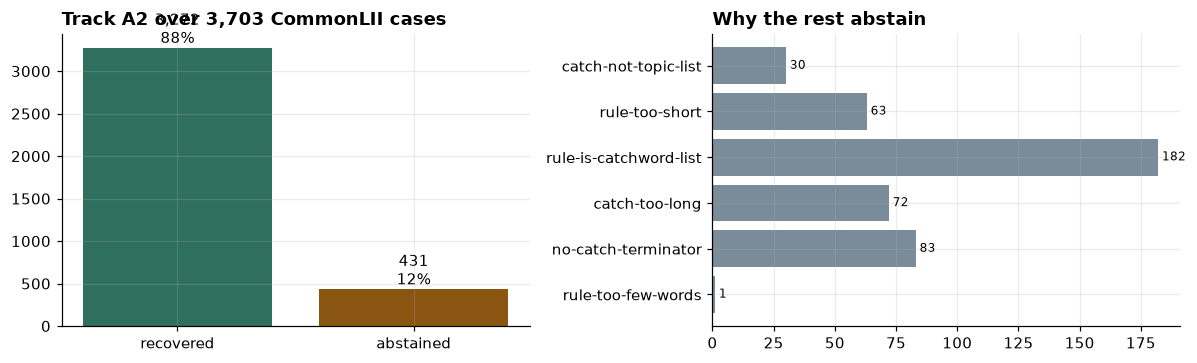

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(["recovered", "abstained"], [parsed, abst], color=[PAL[0], PAL[3]])
axes[0].set_title(f"Track A2 over {n:,} CommonLII cases", loc="left", fontweight="bold")
for i, v in enumerate([parsed, abst]):
    axes[0].text(i, v, f"{v:,}\n{v/n:.0%}", ha="center", va="bottom")
rk = list(reasons.keys()); rv = list(reasons.values())
axes[1].barh(range(len(rk)), rv, color=PAL[2]); axes[1].set_yticks(range(len(rk)))
axes[1].set_yticklabels(rk); axes[1].invert_yaxis()
axes[1].set_title("Why the rest abstain", loc="left", fontweight="bold")
for i, v in enumerate(rv):
    axes[1].text(v, i, f" {v}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

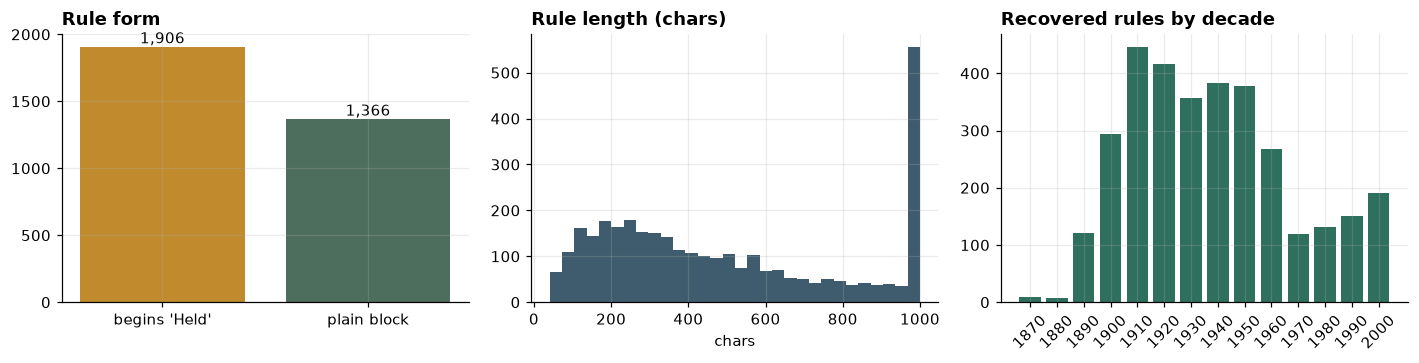

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
held = int(rules_df["begins_held"].sum()); plain = parsed - held
axes[0].bar(["begins 'Held'", "plain block"], [held, plain], color=[PAL[1], PAL[4]])
axes[0].set_title("Rule form", loc="left", fontweight="bold")
for i, v in enumerate([held, plain]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].hist(rules_df["rule"].str.len().clip(upper=1000), bins=30, color=PAL[6])
axes[1].set_title("Rule length (chars)", loc="left", fontweight="bold"); axes[1].set_xlabel("chars")

yr = pd.to_numeric(rules_df["year"], errors="coerce").dropna().astype(int)
dc = (yr // 10 * 10).value_counts().sort_index()
axes[2].bar(dc.index.astype(str), dc.values, color=PAL[0], width=0.8)
axes[2].set_title("Recovered rules by decade", loc="left", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

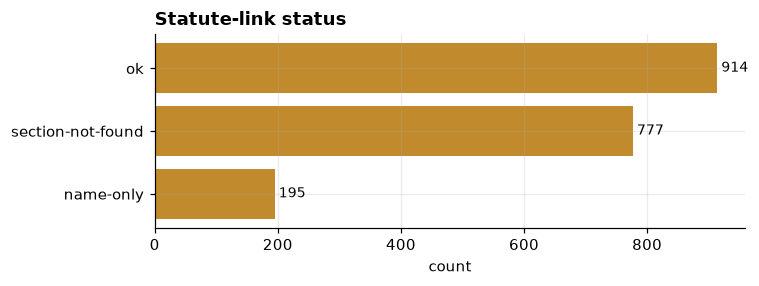

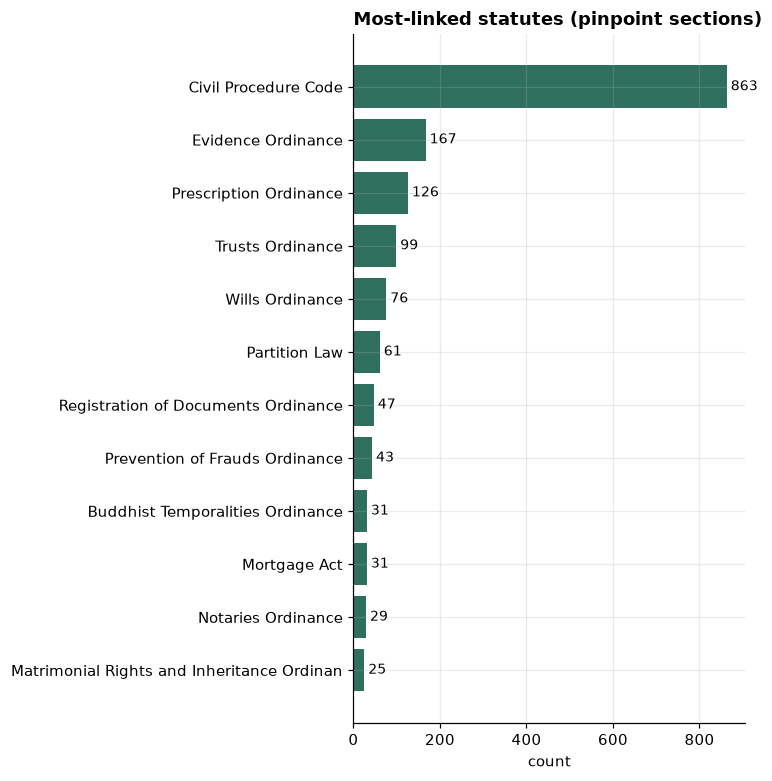

In [9]:
if not links_df.empty:
    st = links_df["status_link"].value_counts()
    barh(st.index.tolist(), st.values.tolist(), "Statute-link status", color=PAL[1])
    named = links_df.dropna(subset=["section"]).merge(
        reg_df[["source_id", "official_title"]], on="source_id", how="left")
    top = named["official_title"].value_counts().head(12)
    if len(top):
        barh([t[:42] for t in top.index], top.values.tolist(),
             "Most-linked statutes (pinpoint sections)", color=PAL[0])

## 5. Manual validation harness

Everything above is **candidate, unverified**. Below is an inline review view
(rule beside its raw source window) and an exported review sheet with blank
verdict columns for a lawyer to fill in. Change `REVIEW_N` and re-run to see more.

In [10]:
REVIEW_N = 15
random.seed(20)
review_ids = random.sample(list(rules_df["case_id"]), min(REVIEW_N, len(rules_df)))

def source_window(cid, nchars=520):
    t = re.sub(r"\s+", " ", load_text(cid))
    hs = list(HEADER.finditer(t)); t = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(t[:600]));  t = t[navs[-1].end():] if navs else t
    return t[:nchars]

for cid in review_ids:
    row = rules_df[rules_df["case_id"] == cid].iloc[0]
    ls = links_df[links_df["case_id"] == cid]
    print("=" * 92); print(cid, "|", row["citation"])
    print("SOURCE :", source_window(cid)[:340])
    print("-> RULE:", row["rule"])
    if len(ls):
        print("-> LINK:", [(e.source_id, e.section, e.status_link) for e in ls.itertuples()])
    print()

commonlii-LKCA-2005-39 | (2005) 3 Sri LR 138
SOURCE :  138 DAYARATHNE VS STATE MORTGAGE AND INVESTMENT BANK COURT OF APPEAL SRIPAVAN, J, AND BASNAYAKE, J. CA 1417/2004 JULY 1,2005 AUGUST 1, 2005 Writ of certiorari - Resolution passed to parate execute property - Stamp Duty Act, Section 16 - Can the Bank recover anything other than the consideration secured under the Mortgage Bond? . The peti
-> RULE: HELD: Sections 16 and 17 of the Stamp Duty Act have to be interpreted strictly. It is clear that duty is payable only on the principal amount and not on the interest. The mortgage must be stamped to the value of the principal sum only, and no stamp duty is required to be paid on the interest payable. It is untenable to say no interest could be recovered.
-> LINK: [('SRC034', '16', 'ok')]

commonlii-LKCA-1997-48 | (1998) 2 Sri LR 305
SOURCE :  305 GNANASAMBANDAM v. BIN ADAHAM AND ANOTHER COURT OF APPEAL WEERASEKERA, J. & WIGNESWARAN, J. C.A. NO. 791/88 (F) D.C. AVISSAWELLA NO. 17610/1 JANUA

In [11]:
rules_df.to_csv(OUT / "rules_recovered.csv", index=False)
links_df.to_csv(OUT / "statute_links.csv", index=False)

review = rules_df.sample(min(60, len(rules_df)), random_state=20).copy()
review["statute_links"] = review["case_id"].map(
    lambda c: "; ".join(f"{e.source_id}:{e.section}" for e in links_df[links_df.case_id == c].itertuples() if e.section))
for col in ["rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]:
    review[col] = ""
review = review[["case_id", "citation", "catchwords", "rule", "statute_links",
                 "rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]]
review.to_csv(OUT / "review-sample.csv", index=False)
print("wrote:", OUT / "rules_recovered.csv")
print("      ", OUT / "statute_links.csv")
print("      ", OUT / "review-sample.csv", f"({len(review)} rows for lawyer sign-off)")

wrote: C:\Users\ASUS\Desktop\DSEP\Draftly\evaluation\runs\headnote-recovery-v1\rules_recovered.csv
       C:\Users\ASUS\Desktop\DSEP\Draftly\evaluation\runs\headnote-recovery-v1\statute_links.csv
       C:\Users\ASUS\Desktop\DSEP\Draftly\evaluation\runs\headnote-recovery-v1\review-sample.csv (60 rows for lawyer sign-off)


## 6. Takeaways

- Track A2 recovers a verbatim rule from **88.4%** of the 3,703 CommonLII
  judgments (3,272 cases; up from 3,258/88.0% before this hardening pass, and
  from 524 via the original `Held:`-only extractor), with no LLM spend and no
  dependence on the missing LawNet headnotes.
- This pass hardened three specific, verified-safe structural gaps rather than
  loosening any precision guard:
  1. **Corrupted dash recovery.** 899 of the 3,703 harvested `.txt` files have
     lost their original em-dash byte during the CommonLII harvest/encoding
     step, leaving the Unicode replacement character (`�`) in its place.
     A separate, broadened dash pattern (`DASH_CATCH`, catchword-boundary
     detection only) now treats `�` and doubled hyphens (`--`) as valid
     topic separators, while the original narrow `DASH` pattern is kept
     untouched for the rule-content catchword-list guard so precision there
     is unaffected.
  2. **Quote-abutting terminators.** Catchword lists ending `..." Judge, J.`
     (closing quote directly against the period, no space) were rejected by
     the terminator regex, which required whitespace immediately after the
     period. Fixed to allow an optional immediate quote first.
  3. **Fact-narrative bleed.** The `BODY` stop-marker recognised `"THE facts"`
     but not the equally common `"THIS action/appeal/suit/case was..."`
     construction, so 7 cases were pulling 150-600 characters of case facts
     into the "rule" before stopping. Extended `BODY` to catch both forms.
  - Two follow-on attempts (allowing a bare `.` before a dash to catch
    `"et seq.-Topic"`; excluding only `v.`/`vs.` from that with a lookbehind)
    were tested, found net-negative on the full corpus even after guarding,
    and reverted. Recall was not allowed to win over precision.
- **Known, documented limitation (pre-existing, not introduced by this pass):**
  the `HELD` marker match is not anchored to sentence-start, so ordinary
  prose uses of "held" as a verb (*"...who held a power of attorney..."*,
  *"...land held by them in common..."*, *"...at the sale held by the
  Fiscal..."*) can occasionally be mistaken for the editorial "Held," marker.
  A 50-case random precision audit across two seeds found this in an
  estimated ~6-8% of recovered cases (confirmed present in the original,
  unhardened parser too — verified directly against the pre-session baseline).
  Distinguishing genuine markers (which are not reliably signalled by
  capitalisation or trailing punctuation — both forms are used across NLR
  eras) from ordinary verb usage needs either a small labelled set or a
  narrower, corpus-validated heuristic than time allowed here; flagging for
  the next hardening pass rather than shipping a rushed fix. Everything
  downstream of `status=unverified` exists precisely to catch this class of
  error before it reaches a lawyer-facing answer.
- It remains **precision-first**: 11.6% abstain (jumbled OCR, no dash-list
  headnote, atypical layout, single-topic catchwords with no dash at all) and
  flow to the bounded LLM track rather than emit a non-rule. The hard guard
  rejecting any candidate with 4+ topic-dashes (i.e. itself a catchword list)
  was kept intact throughout this pass and re-verified against the full
  corpus after every change.
- Two random 25-case precision audits (50 cases total, two seeds) found the
  large majority (~84-92%) to be genuine ratios, with the "held"-as-verb
  pattern above as the main recurring defect class; the review sheet remains
  the authoritative gate, not this audit.
- Statute links are taken straight from the headnote (the editor's own
  statement of the governing provision) and validated against the section
  index where the statute is in the catalogue; out-of-catalogue citations keep
  a name/verbatim reference.
- **Everything is `status=unverified`.** These are yield and precision-audit
  numbers, not legal-correctness scores; lawyer review of `review-sample.csv`
  (statute attribution especially, and the "held"-as-verb class flagged above)
  is required before any rule or link is treated as authority.
